# plotting

> Set of functions and classes to make plotting easier

In [ ]:
#| default_exp plotting

In [ ]:
#| hide
from eccore.ipython import nb_setup
from nbdev.showdoc import show_doc
from myquantlab.core import load_test_df

In [ ]:
#| hide
nb_setup()

Set autoreload mode


In [ ]:
#| export
from datetime import datetime
from pathlib import Path
from typing import Callable, Iterable, Optional

import matplotlib.pyplot as plt
import matplotlib.dates as mdates


import numpy as np
import pandas as pd
from matplotlib.axes import Axes
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from myquantlab.core import load_test_df

In [ ]:
#| export
def plot_timeseries(
    *tseries: pd.Series,    # one of several np.Series with DataTimeIndex
    ax:Optional[Axes]=None, # axis to plot    
    add_legend:bool=False   # add legend to plot, when True
    ) -> None:
    if ax is None:
        fig, ax = plt.subplots()

    if not isinstance(tseries, tuple):
        tseries = (tseries,)
    for i, ts in enumerate(tseries):
        label = getattr(ts, "name", str(i))
        ax.plot(ts, alpha=0.5, label=label)
    if add_legend:
        ax.legend()
    plt.show()

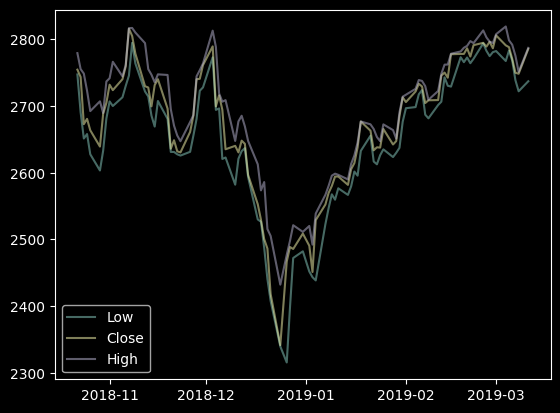

In [ ]:
df = load_test_df()
plot_timeseries(df.Low, df.Close, df.High, add_legend=True)

In [ ]:
#| export
def plot_two_color_line(
    s:pd.Series, # Data to plot as a pd.Series with DateTimeIndex
    cond: pd.Series | np.ndarray, # boolean condition defining the colors to apply (same length as s)
    cond_labels=("Up", "Down"), # labels for the condition to be used in the legend
    ax: plt.Axes | None = None, # ax where to plot; if None, a new figure and ax will be created and shown
    linestyle='-',  # '-' or 'solid'; '--' or 'dashed'; ':' or 'dotted'; '-.' or 'dashdot'
    figsize=(10, 6), 
    colors=("#0D8821", "#D13F05"), 
    ):
    if ax is None:
        plot_axes = True
        fig, ax = plt.subplots(figsize=figsize)
    else:
        plot_axes = False
    
    assert isinstance(s.index, pd.DatetimeIndex), "Expected DateTimeIndex for x-axis"
    # convert datetime index to matplotlib's numeric format for plotting
    x = mdates.date2num(s.index.to_pydatetime())
    y = s.to_numpy()
    cond = cond if isinstance(cond, np.ndarray) else cond.to_numpy()
    assert len(cond) == len(y), "Condition series must have same length as series"

    # Build contiguous line segments: [(x0,y0)->(x1,y1)], [(x1,y1)->(x2,y2)], ...
    points = np.column_stack([x, y]).reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # One color per segment (use cond at segment start)
    seg_colors = np.where(cond[:-1], colors[0], colors[1])

    had_data = ax.has_data()
    lc = LineCollection(segments, colors=seg_colors, linestyle=linestyle, linewidths=1.75)
    ax.add_collection(lc)

    x_min, x_max = x.min(), x.max()
    y_min, y_max = np.nanmin(y), np.nanmax(y)
    if had_data:
        cur_xmin, cur_xmax = ax.get_xlim()
        cur_ymin, cur_ymax = ax.get_ylim()
        x_min, x_max = min(x_min, cur_xmin), max(x_max, cur_xmax)
        y_min, y_max = min(y_min, cur_ymin), max(y_max, cur_ymax)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.xaxis_date()

    existing_legend = ax.get_legend()
    if existing_legend is None:
        legend_handles, legend_labels = [], []
    else:
        legend_handles = list(existing_legend.legend_handles)
        legend_labels = [t.get_text() for t in existing_legend.get_texts()]
    known_labels = set(legend_labels)

    # Add condition color meaning only once
    for lbl, col in zip(cond_labels, colors):
        if lbl not in known_labels:
            legend_handles.append(Line2D([0], [0], color=col, lw=2, label=lbl))
            legend_labels.append(lbl)
            known_labels.add(lbl)

    # Add a per-series style handle using default foreground color
    series_label = s.name if getattr(s, "name", None) else "series"
    if series_label not in known_labels:
        fg = plt.rcParams.get("text.color", "black")
        legend_handles.append(Line2D([0], [0], color=fg, lw=2, linestyle=linestyle, label=series_label))
        legend_labels.append(series_label)

    ax.legend(handles=legend_handles, labels=legend_labels, loc='lower left')
    if plot_axes: plt.show()

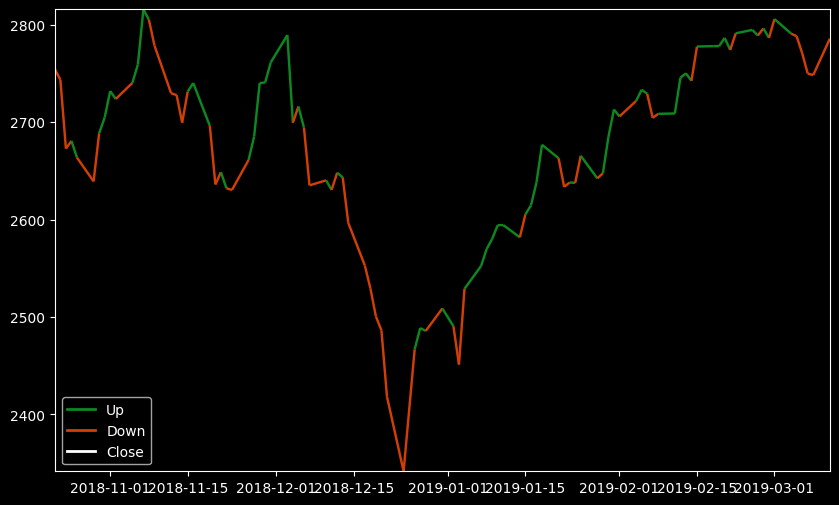

In [ ]:
df = load_test_df()
df['R'] = df.Close.pct_change()

cond = df['R'] > 0
plot_two_color_line(df['Close'], cond)

It is also possible to add a conditional line to an existing axes

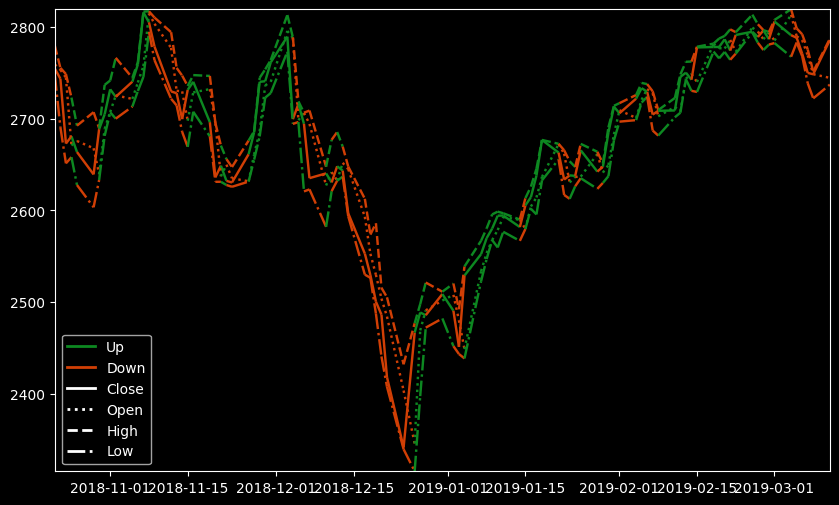

In [ ]:
df = load_test_df()
df['R'] = df.Close.pct_change()
cond = df['R'] > 0

fig, ax = plt.subplots(figsize=(10, 6))
plot_two_color_line(df['Close'], cond, ax=ax)
plot_two_color_line(df['Open'], cond, ax=ax, linestyle=':')
plot_two_color_line(df['High'], cond, ax=ax, linestyle='--')
plot_two_color_line(df['Low'], cond, ax=ax, linestyle='-.')
plt.show()


In [ ]:
#| export
def hist_timeseries(
    *tseries: pd.Series, 
    ax:Optional[Axes]=None
    ) -> None:

    if not isinstance(tseries, tuple):
        tseries = (tseries,)
    ntseries = len(tseries)
    if ax is None:
        fig, axs = plt.subplots(nrows=1, ncols=ntseries, figsize=(5 * ntseries, 4))
        if not isinstance(axs, np.ndarray): # single axis
            axs = (axs,)
    else:
        axs = (ax,)
    for ax, ts in zip(axs, tseries):
        n = ts.shape[0]
        bins = n // 10
        rng = np.random.default_rng()
        z = rng.normal(loc=ts.mean(), scale=ts.std(), size=n)

        ax.hist(ts, bins=bins, histtype='step', label='TS')      # type: ignore
        ax.hist(z, bins=bins, histtype='step', label='Gaussian') # type: ignore
        ax.legend() # type: ignore
    plt.show()


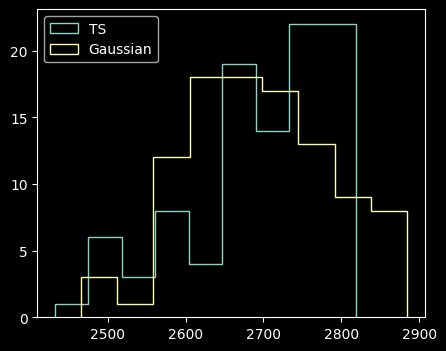

In [ ]:
hist_timeseries(df.High)

In [ ]:
#| export
def plot_acfs(*tseries, incl_lag0=False, alpha=0.05, ax=None):
    for ts in tseries:
        if ax is None:
            _, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 4))
        else:
            axes = ax
        plot_acf(ts.dropna(), ax=axes[0], zero=incl_lag0, alpha=alpha)
        plot_pacf(ts.dropna(), ax=axes[1], zero=incl_lag0, alpha=alpha)


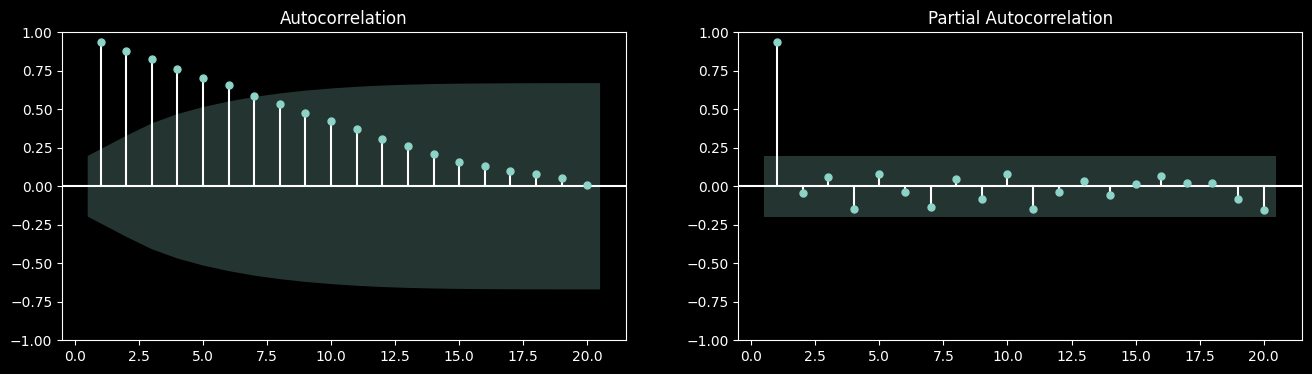

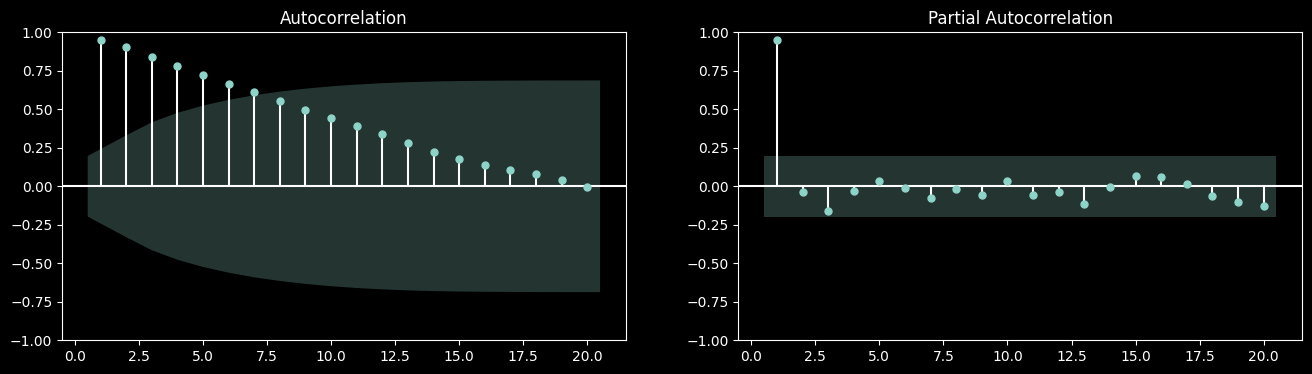

In [ ]:
plot_acfs(df.Close, df.High)

In [ ]:
#| export
def normal_probability_plot(*tseries, ax=None):
    ntseries = len(tseries)
    if not isinstance(tseries, tuple):
        tseries = (tseries,)

    if ax is None:
        fig, axs = plt.subplots(nrows=1, ncols=ntseries, figsize=(5 * ntseries, 4), sharey=True)
        if not isinstance(axs, np.ndarray):
            axs = (axs,)
    else:
        axs = (ax,)

    for ax, ts in zip(axs, tseries):
        (_, (slope, intercept, r)) = stats.probplot(ts, dist='norm', fit=True, plot=ax)
        ax.set_title(f"Normal Probability Plot (R2 = {r:.3f})")

    plt.show()


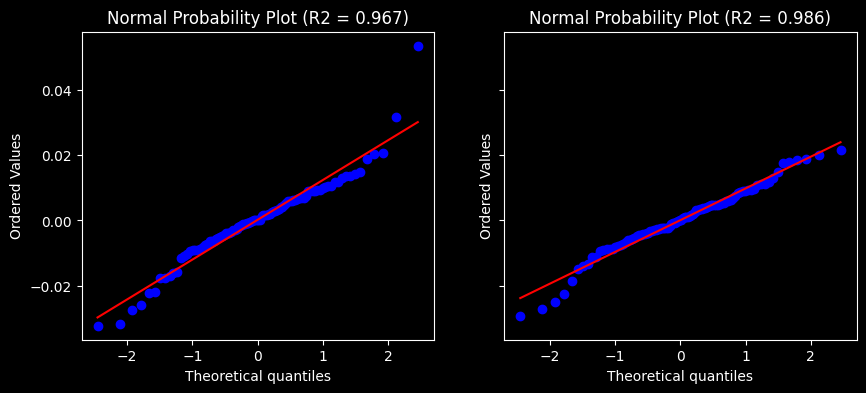

In [ ]:
normal_probability_plot(df.Close.pct_change().dropna(), df.High.pct_change().dropna())

In [ ]:
#| hide
import nbdev
nbdev.nbdev_export()